**Titanic_Dataset_Naive_Bayes**

In [80]:
%matplotlib inline

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [82]:
df = pd.read_csv(r"C:\Users\LaptopWala\Downloads\archive (2)\Titanic-Dataset.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [83]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Titanic Dataset Profiling Report", explorative=True)
profile.to_file("Titanic_Dataset_Profiling_Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 166.00it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [84]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Fare', 'Embarked',], errors='ignore')
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0


In [86]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Age'].isnull().sum()

np.int64(0)

In [93]:
df['Age'].skew()


np.float64(0.4344880940129925)

In [92]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Sex'].dtype == 'int64'
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,1,22.0,1,0
1,1,1,0,38.0,1,0
2,1,3,0,26.0,0,0
3,1,1,0,35.0,1,0
4,0,3,1,35.0,0,0


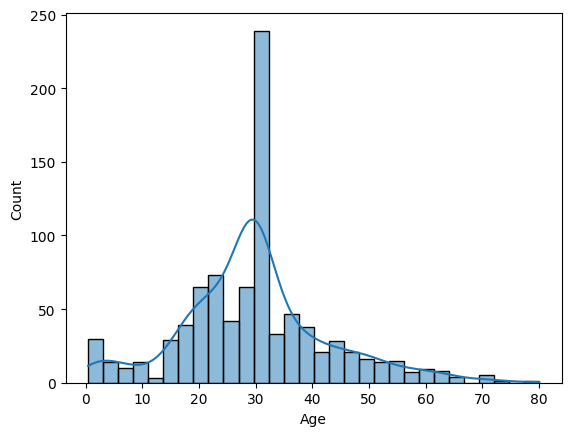

In [94]:
sns.histplot(df['Age'], kde = True)
plt.show()

In [109]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,FamilySize,IsAlone
0,0,3,1,22.0,1,0,2,0
1,1,1,0,38.0,1,0,2,0
2,1,3,0,26.0,0,0,1,1
3,1,1,0,35.0,1,0,2,0
4,0,3,1,35.0,0,0,1,1


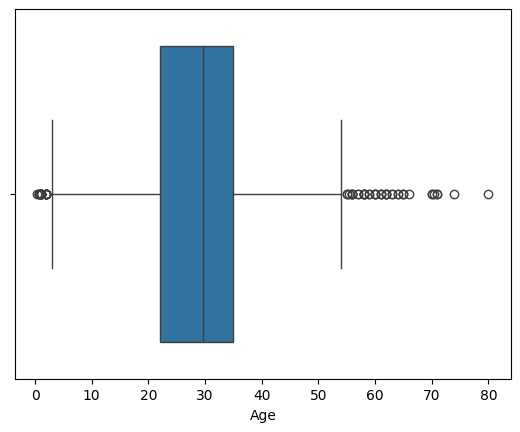

In [96]:
sns.boxplot(x=df['Age'])
plt.show()

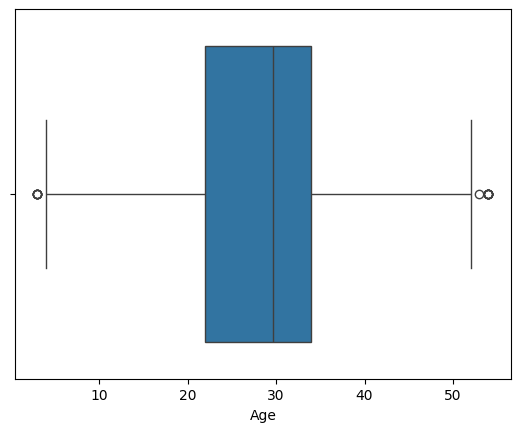

In [97]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)   
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]
sns.boxplot(x=df['Age'])
plt.show()

In [110]:
X = df.drop('Survived', axis = 1 )
y = df['Survived']

In [111]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test)

(660, 165)

In [112]:
len(df)

825

In [113]:
X_train

,Pclass,Sex,Age,SibSp,Parch,FamilySize,IsAlone
260,3,1,29.699118,0,0,1,1
744,3,1,31.000000,0,0,1,1
699,3,1,42.000000,0,0,1,1
371,3,1,18.000000,1,0,2,0
325,1,0,36.000000,0,0,1,1
...,...,...,...,...,...,...,...
77,3,1,29.699118,0,0,1,1
115,3,1,21.000000,0,0,1,1
294,3,1,24.000000,0,0,1,1
470,3,1,29.699118,0,0,1,1


In [114]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

In [115]:
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [116]:
y_pred = model.predict(X_test)

In [117]:
y_test

663    0
191    0
73     0
185    0
300    1
      ..
316    1
230    1
521    0
832    0
571    1
Name: Survived, Length: 165, dtype: int64

In [118]:
from sklearn.metrics import accuracy_score  
accuracy_score(y_test, y_pred)

0.7878787878787878

In [119]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy is: {test_acc:.2f}")

Training Accuracy: 0.79
Testing Accuracy is: 0.79


In [120]:

from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.76      0.81        99
           1       0.70      0.83      0.76        66

    accuracy                           0.79       165
   macro avg       0.78      0.80      0.78       165
weighted avg       0.80      0.79      0.79       165

Confusion Matrix:
 [[75 24]
 [11 55]]
